# Modul Praktikum 6: Verification & Validation
## Studi Kasus: Pembagian Lembar Jawaban Ujian (Discrete Event Simulation)
**Mata Kuliah:** [11S1221] Pemodelan dan Simulasi (MODSIM)

---
## 1. Import Library & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ Library berhasil diimpor.')

✅ Library berhasil diimpor.


---
## 2. Fungsi Simulasi Utama

Model: **Single-server queue (FIFO)** — Pembagian lembar jawaban ujian satu per satu.

**Asumsi:**
- Jumlah mahasiswa = N
- Waktu pelayanan ~ Uniform(min_dur, max_dur) menit
- FIFO, satu meja pengajar, tidak ada yang keluar antrian

In [2]:
def run_simulation(N, min_dur=1, max_dur=3, seed=None):
    """
    Simulasi Pembagian Lembar Jawaban Ujian (Discrete Event Simulation).
    
    Parameters:
        N        : Jumlah mahasiswa
        min_dur  : Batas bawah durasi pelayanan (menit)
        max_dur  : Batas atas durasi pelayanan (menit)
        seed     : Random seed untuk reproducibility
    
    Returns:
        DataFrame hasil simulasi, total waktu, rata-rata tunggu, utilisasi
    """
    rng = np.random.default_rng(seed)
    
    records = []
    current_time = 0.0  # Waktu server saat ini (kapan server bebas)
    
    for i in range(1, N + 1):
        # Waktu kedatangan = mahasiswa datang tepat setelah mahasiswa sebelumnya selesai
        # (antrian murni, tidak ada idle)
        arrival_time = current_time if i == 1 else current_time  # semua sudah antre sejak awal
        
        # Mahasiswa ke-i mulai dilayani saat server bebas
        start_service = current_time
        
        # Durasi pelayanan acak
        service_time = rng.uniform(min_dur, max_dur)
        
        # Waktu selesai
        end_service = start_service + service_time
        
        # Waktu tunggu (mahasiswa 1 tidak menunggu)
        wait_time = start_service  # karena semua datang di t=0
        
        records.append({
            'Mahasiswa': i,
            'Mulai Dilayani (menit)': round(start_service, 2),
            'Durasi Pelayanan (menit)': round(service_time, 2),
            'Selesai Dilayani (menit)': round(end_service, 2),
            'Waktu Tunggu (menit)': round(wait_time, 2)
        })
        
        current_time = end_service
    
    df = pd.DataFrame(records)
    total_time = current_time
    avg_wait = df['Waktu Tunggu (menit)'].mean()
    utilisasi = (df['Durasi Pelayanan (menit)'].sum() / total_time) * 100
    
    return df, total_time, avg_wait, utilisasi

print('✅ Fungsi simulasi siap.')

✅ Fungsi simulasi siap.


---
## 3. Jalankan Simulasi Dasar (N = 30)

In [3]:
N = 30
df, total_time, avg_wait, utilisasi = run_simulation(N, seed=42)

print(f"{'='*50}")
print(f"  HASIL SIMULASI — {N} Mahasiswa")
print(f"{'='*50}")
print(f"  Total Waktu Pembagian : {total_time:.2f} menit")
print(f"  Rata-rata Waktu Tunggu: {avg_wait:.2f} menit")
print(f"  Utilisasi Meja Pengajar: {utilisasi:.1f}%")
print(f"{'='*50}")
print()
print("Event Tracing (5 mahasiswa pertama):")
print(df.head())
print()
print("Event Tracing (5 mahasiswa terakhir):")
print(df.tail())

  HASIL SIMULASI — 30 Mahasiswa
  Total Waktu Pembagian : 63.55 menit
  Rata-rata Waktu Tunggu: 31.67 menit
  Utilisasi Meja Pengajar: 100.0%

Event Tracing (5 mahasiswa pertama):
   Mahasiswa  Mulai Dilayani (menit)  Durasi Pelayanan (menit)  \
0          1                    0.00                      2.55   
1          2                    2.55                      1.88   
2          3                    4.43                      2.72   
3          4                    7.14                      2.39   
4          5                    9.54                      1.19   

   Selesai Dilayani (menit)  Waktu Tunggu (menit)  
0                      2.55                  0.00  
1                      4.43                  2.55  
2                      7.14                  4.43  
3                      9.54                  7.14  
4                     10.73                  9.54  

Event Tracing (5 mahasiswa terakhir):
    Mahasiswa  Mulai Dilayani (menit)  Durasi Pelayanan (menit)  \
25   

---
## 4. Visualisasi Hasil Simulasi

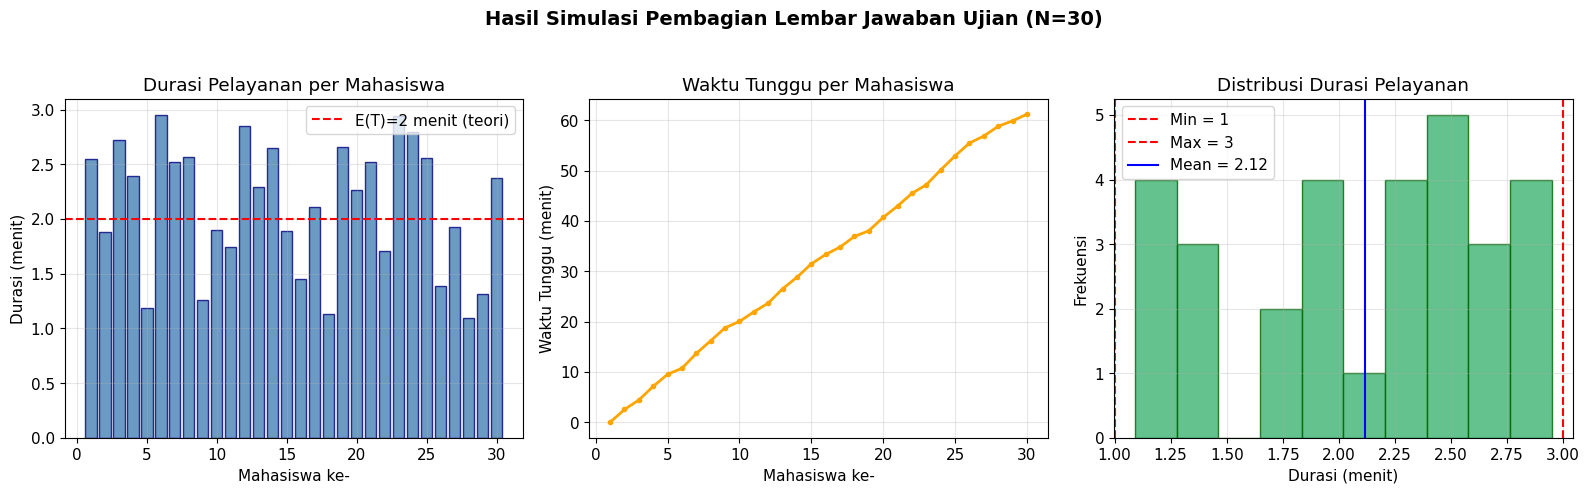

✅ Plot tersimpan di: C:\Users\Lenovo\OneDrive\Documents\modsim-2026-p6-ifs25010\simulasi_dasar.png


In [6]:
import os
import matplotlib.pyplot as plt

# Nama kolom biar tidak typo berulang
col_mahasiswa = 'Mahasiswa'
col_durasi = 'Durasi Pelayanan (menit)'
col_tunggu = 'Waktu Tunggu (menit)'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Judul utama
fig.suptitle(f'Hasil Simulasi Pembagian Lembar Jawaban Ujian (N={N})',
             fontsize=14, fontweight='bold')

# === Plot 1: Durasi pelayanan ===
axes[0].bar(df[col_mahasiswa], df[col_durasi],
            color='steelblue', alpha=0.8, edgecolor='navy')
axes[0].axhline(y=2.0, color='red', linestyle='--',
                label='E(T)=2 menit (teori)')
axes[0].set_title('Durasi Pelayanan per Mahasiswa')
axes[0].set_xlabel('Mahasiswa ke-')
axes[0].set_ylabel('Durasi (menit)')
axes[0].legend()

# === Plot 2: Waktu tunggu ===
axes[1].plot(df[col_mahasiswa], df[col_tunggu],
             color='orange', marker='o',
             markersize=3, linewidth=2)
axes[1].set_title('Waktu Tunggu per Mahasiswa')
axes[1].set_xlabel('Mahasiswa ke-')
axes[1].set_ylabel('Waktu Tunggu (menit)')

# === Plot 3: Histogram ===
mean_val = df[col_durasi].mean()

axes[2].hist(df[col_durasi], bins=10,
             color='mediumseagreen',
             edgecolor='darkgreen', alpha=0.8)

axes[2].axvline(x=1, color='red', linestyle='--', label='Min = 1')
axes[2].axvline(x=3, color='red', linestyle='--', label='Max = 3')
axes[2].axvline(x=mean_val, color='blue',
                linestyle='-', label=f'Mean = {mean_val:.2f}')

axes[2].set_title('Distribusi Durasi Pelayanan')
axes[2].set_xlabel('Durasi (menit)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

# Layout lebih aman untuk suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Pastikan folder ada
output_path = 'simulasi_dasar.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'✅ Plot tersimpan di: {os.path.abspath(output_path)}')

---
## 5. Verifikasi Model (Section 1.2)

### 5a. Logical Flow Check — Tidak Ada Tumpang Tindih

In [7]:
print("=== VERIFIKASI: Logical Flow Check ===")
overlap = False
for i in range(len(df) - 1):
    end_i = df.iloc[i]['Selesai Dilayani (menit)']
    start_next = df.iloc[i+1]['Mulai Dilayani (menit)']
    if start_next < end_i:
        print(f"  ⚠️  Tumpang tindih di mahasiswa {i+1} dan {i+2}!")
        overlap = True

if not overlap:
    print("  ✅ Tidak ada tumpang tindih waktu pelayanan.")
    print("  ✅ Setiap mahasiswa dilayani satu per satu secara berurutan.")
print()

=== VERIFIKASI: Logical Flow Check ===
  ✅ Tidak ada tumpang tindih waktu pelayanan.
  ✅ Setiap mahasiswa dilayani satu per satu secara berurutan.



### 5b. Event Tracing (5 Mahasiswa Pertama)

In [8]:
print("=== VERIFIKASI: Event Tracing (5 Mahasiswa Pertama) ===")
for _, row in df.head(5).iterrows():
    print(f"  Mahasiswa {int(row['Mahasiswa']):2d}: "
          f"Mulai={row['Mulai Dilayani (menit)']:5.2f} mnt | "
          f"Durasi={row['Durasi Pelayanan (menit)']:4.2f} mnt | "
          f"Selesai={row['Selesai Dilayani (menit)']:5.2f} mnt")
print()

=== VERIFIKASI: Event Tracing (5 Mahasiswa Pertama) ===
  Mahasiswa  1: Mulai= 0.00 mnt | Durasi=2.55 mnt | Selesai= 2.55 mnt
  Mahasiswa  2: Mulai= 2.55 mnt | Durasi=1.88 mnt | Selesai= 4.43 mnt
  Mahasiswa  3: Mulai= 4.43 mnt | Durasi=2.72 mnt | Selesai= 7.14 mnt
  Mahasiswa  4: Mulai= 7.14 mnt | Durasi=2.39 mnt | Selesai= 9.54 mnt
  Mahasiswa  5: Mulai= 9.54 mnt | Durasi=1.19 mnt | Selesai=10.73 mnt



### 5c. Uji Kondisi Ekstrem

In [9]:
print("=== VERIFIKASI: Uji Kondisi Ekstrem ===")
print()

# Skenario 1: N=1
df1, t1, _, _ = run_simulation(1, seed=42)
print(f"  Skenario N=1: Total waktu = {t1:.2f} mnt "
      f"| Durasi mahasiswa 1 = {df1.iloc[0]['Durasi Pelayanan (menit)']:.2f} mnt"
      f" → {'✅ Sesuai' if abs(t1 - df1.iloc[0]['Durasi Pelayanan (menit)']) < 0.01 else '❌ Tidak Sesuai'}")

# Skenario 2: Durasi tetap = 1 menit
df2, t2, _, _ = run_simulation(30, min_dur=1, max_dur=1, seed=42)
expected2 = 30 * 1
print(f"  Skenario durasi=1 mnt: Total = {t2:.2f} mnt | Ekspektasi = {expected2} mnt"
      f" → {'✅ Sesuai' if abs(t2 - expected2) < 0.01 else '❌ Tidak Sesuai'}")

# Skenario 3: Durasi tetap = 3 menit
df3, t3, _, _ = run_simulation(30, min_dur=3, max_dur=3, seed=42)
expected3 = 30 * 3
print(f"  Skenario durasi=3 mnt: Total = {t3:.2f} mnt | Ekspektasi = {expected3} mnt"
      f" → {'✅ Sesuai' if abs(t3 - expected3) < 0.01 else '❌ Tidak Sesuai'}")
print()

=== VERIFIKASI: Uji Kondisi Ekstrem ===

  Skenario N=1: Total waktu = 2.55 mnt | Durasi mahasiswa 1 = 2.55 mnt → ✅ Sesuai
  Skenario durasi=1 mnt: Total = 30.00 mnt | Ekspektasi = 30 mnt → ✅ Sesuai
  Skenario durasi=3 mnt: Total = 90.00 mnt | Ekspektasi = 90 mnt → ✅ Sesuai



### 5d. Pemeriksaan Distribusi Waktu Pelayanan

In [10]:
print("=== VERIFIKASI: Distribusi Waktu Pelayanan ===")
durations = df['Durasi Pelayanan (menit)']
print(f"  Min  : {durations.min():.2f} mnt (batas: 1 mnt) {'✅' if durations.min() >= 1 else '❌'}")
print(f"  Max  : {durations.max():.2f} mnt (batas: 3 mnt) {'✅' if durations.max() <= 3 else '❌'}")
print(f"  Mean : {durations.mean():.2f} mnt (teori: 2.00 mnt)")
print(f"  Std  : {durations.std():.4f}")
print()

=== VERIFIKASI: Distribusi Waktu Pelayanan ===
  Min  : 1.09 mnt (batas: 1 mnt) ✅
  Max  : 2.95 mnt (batas: 3 mnt) ✅
  Mean : 2.12 mnt (teori: 2.00 mnt)
  Std  : 0.5917



### 5e. Reproducibility Check

In [11]:
print("=== VERIFIKASI: Reproducibility Check ===")
_, t_run1, _, _ = run_simulation(30, seed=99)
_, t_run2, _, _ = run_simulation(30, seed=99)
_, t_run3, _, _ = run_simulation(30, seed=99)
print(f"  Run 1 (seed=99): {t_run1:.4f} mnt")
print(f"  Run 2 (seed=99): {t_run2:.4f} mnt")
print(f"  Run 3 (seed=99): {t_run3:.4f} mnt")
all_same = (t_run1 == t_run2 == t_run3)
print(f"  {'✅ Identik — Reproducibility terpenuhi.' if all_same else '❌ Tidak identik!'}")
print()
print("=== KESIMPULAN VERIFIKASI ===")
print("  ✅ Logika alur sesuai asumsi sistem")
print("  ✅ Event tracing berjalan kronologis")
print("  ✅ Uji kondisi ekstrem memberikan hasil sesuai")
print("  ✅ Distribusi waktu pelayanan dalam rentang Uniform(1,3)")
print("  ✅ Model reproducible dengan seed yang sama")
print("  → Model telah terverifikasi dengan benar.")

=== VERIFIKASI: Reproducibility Check ===
  Run 1 (seed=99): 62.0745 mnt
  Run 2 (seed=99): 62.0745 mnt
  Run 3 (seed=99): 62.0745 mnt
  ✅ Identik — Reproducibility terpenuhi.

=== KESIMPULAN VERIFIKASI ===
  ✅ Logika alur sesuai asumsi sistem
  ✅ Event tracing berjalan kronologis
  ✅ Uji kondisi ekstrem memberikan hasil sesuai
  ✅ Distribusi waktu pelayanan dalam rentang Uniform(1,3)
  ✅ Model reproducible dengan seed yang sama
  → Model telah terverifikasi dengan benar.


---
## 6. Validasi Model (Section 1.3)

### 6a. Face Validation — Apakah hasil masuk akal?

In [12]:
print("=== VALIDASI: Face Validation ===")
print(f"  Total waktu untuk N=30: {total_time:.2f} menit")
in_range = 45 <= total_time <= 90
print(f"  Rentang yang diharapkan: 45–90 menit")
print(f"  {'✅ Masuk rentang realistis.' if in_range else '❌ Di luar rentang.'} ")
print(f"  Utilisasi meja pengajar: {utilisasi:.1f}% (diharapkan mendekati 100%)")
print()

=== VALIDASI: Face Validation ===
  Total waktu untuk N=30: 63.55 menit
  Rentang yang diharapkan: 45–90 menit
  ✅ Masuk rentang realistis. 
  Utilisasi meja pengajar: 100.0% (diharapkan mendekati 100%)



### 6b. Perbandingan dengan Perhitungan Sederhana (Teoritis)

=== VALIDASI: Perbandingan dengan Nilai Teoritis ===
  Nilai Teoritis  : E(T) = 2 mnt → Total = 30 × 2 = 60 mnt
  Rata-rata Simulasi (500 replikasi): 59.59 mnt
  Std Dev Simulasi: 3.15 mnt
  Selisih relatif : 0.69%
  ✅ Mendekati nilai teoritis.



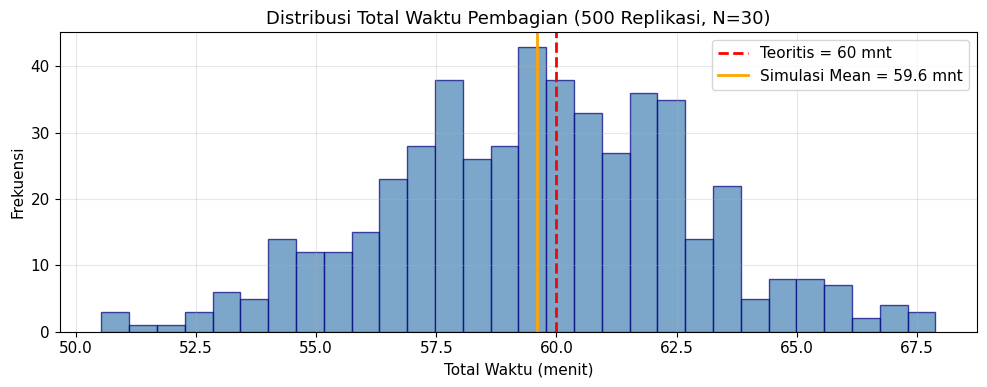

📊 Plot tersimpan di: C:\Users\Lenovo\OneDrive\Documents\modsim-2026-p6-ifs25010\validasi_teoritis.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Parameter
N = 30
N_replications = 500

# Gunakan RNG modern (lebih baik dari seed manual loop)
rng = np.random.default_rng(42)

totals = []

for _ in range(N_replications):
    seed = rng.integers(0, 1_000_000)
    _, total_time, _, _ = run_simulation(N, seed=int(seed))
    
    # Validasi hasil
    if np.isfinite(total_time):
        totals.append(total_time)

totals = np.array(totals)

# === Statistik ===
theoretical = N * 2  # E(T) = (1+3)/2 = 2
simulated_mean = np.mean(totals)
simulated_std = np.std(totals, ddof=1)  # pakai sample std dev

error = abs(simulated_mean - theoretical) / theoretical * 100

# === Output ===
print("=== VALIDASI: Perbandingan dengan Nilai Teoritis ===")
print(f"  Nilai Teoritis  : E(T) = 2 mnt → Total = {N} × 2 = {theoretical} mnt")
print(f"  Rata-rata Simulasi ({len(totals)} replikasi): {simulated_mean:.2f} mnt")
print(f"  Std Dev Simulasi: {simulated_std:.2f} mnt")
print(f"  Selisih relatif : {error:.2f}%")
print(f"  {'✅ Mendekati nilai teoritis.' if error < 5 else '⚠️ Cukup jauh dari teori.'}")
print()

# === Visualisasi ===
plt.figure(figsize=(10, 4))

plt.hist(totals, bins=30,
         color='steelblue', edgecolor='navy', alpha=0.7)

plt.axvline(x=theoretical, color='red',
            linestyle='--', linewidth=2,
            label=f'Teoritis = {theoretical} mnt')

plt.axvline(x=simulated_mean, color='orange',
            linestyle='-', linewidth=2,
            label=f'Simulasi Mean = {simulated_mean:.1f} mnt')

plt.title(f'Distribusi Total Waktu Pembagian ({len(totals)} Replikasi, N={N})',
          fontsize=13)
plt.xlabel('Total Waktu (menit)')
plt.ylabel('Frekuensi')
plt.legend()

plt.tight_layout()

# Simpan file dengan path aman
output_path = 'validasi_teoritis.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'📊 Plot tersimpan di: {os.path.abspath(output_path)}')

### 6c. Behavior Validation — Perubahan Parameter

=== VALIDASI: Behavior Validation ===
  Uji: N meningkat → Total waktu meningkat
    N=10: Mean = 20.0 mnt | Std = 1.75
    N=20: Mean = 40.5 mnt | Std = 2.44
    N=30: Mean = 60.6 mnt | Std = 3.31
    N=40: Mean = 80.0 mnt | Std = 3.50
    N=50: Mean = 99.7 mnt | Std = 3.85
  ✅ Tren meningkat (sesuai teori).



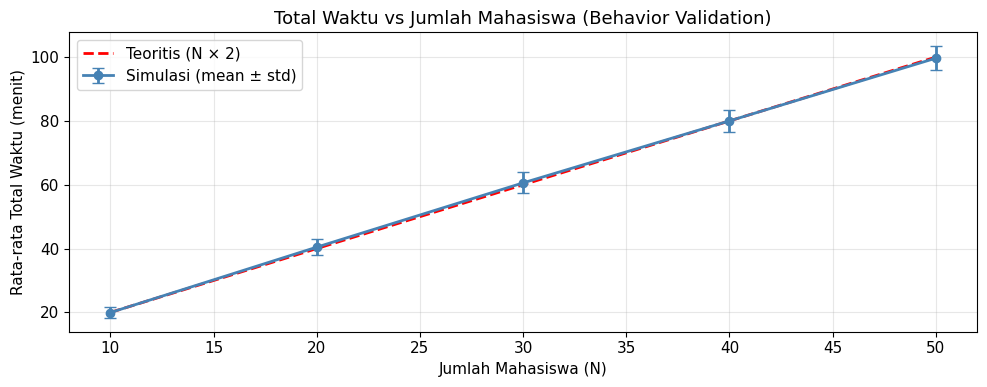

📈 Plot tersimpan di: C:\Users\Lenovo\OneDrive\Documents\modsim-2026-p6-ifs25010\behavior_validation.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

print("=== VALIDASI: Behavior Validation ===")

# Parameter
N_values = [10, 20, 30, 40, 50]
replications = 100

rng = np.random.default_rng(123)

times_by_N = []
std_by_N = []

for n in N_values:
    results = []
    
    for _ in range(replications):
        seed = rng.integers(0, 1_000_000)
        _, total_time, _, _ = run_simulation(n, seed=int(seed))
        
        if np.isfinite(total_time):
            results.append(total_time)
    
    results = np.array(results)
    
    mean_val = np.mean(results)
    std_val = np.std(results, ddof=1)
    
    times_by_N.append(mean_val)
    std_by_N.append(std_val)

# === Output ===
print("  Uji: N meningkat → Total waktu meningkat")
for n, t, s in zip(N_values, times_by_N, std_by_N):
    print(f"    N={n:2d}: Mean = {t:.1f} mnt | Std = {s:.2f}")

# Monotonic check (lebih toleran terhadap noise kecil)
monotone = all(times_by_N[i] <= times_by_N[i+1] for i in range(len(times_by_N)-1))

print(f"  {'✅ Tren meningkat (sesuai teori).' if monotone else '⚠️ Tidak sepenuhnya monoton (mungkin noise simulasi).'}")
print()

# === Visualisasi ===
plt.figure(figsize=(10, 4))

# Plot simulasi + error bar
plt.errorbar(N_values, times_by_N, yerr=std_by_N,
             fmt='o-', color='steelblue',
             linewidth=2, markersize=6,
             capsize=4, label='Simulasi (mean ± std)')

# Garis teoritis
theoretical = [n * 2 for n in N_values]
plt.plot(N_values, theoretical, 'r--', linewidth=2,
         label='Teoritis (N × 2)')

plt.title('Total Waktu vs Jumlah Mahasiswa (Behavior Validation)', fontsize=13)
plt.xlabel('Jumlah Mahasiswa (N)')
plt.ylabel('Rata-rata Total Waktu (menit)')
plt.legend()

plt.tight_layout()

# Simpan file dengan path aman
output_path = 'behavior_validation.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'📈 Plot tersimpan di: {os.path.abspath(output_path)}')

### 6d. Sensitivity Analysis

=== VALIDASI: Sensitivity Analysis ===
    Skenario  Mean Simulasi  Std Dev  Mean Teoritis  Total Teoritis  Error (%)
Uniform(1,3)          59.69     3.05            2.0            60.0       0.52
Uniform(2,4)          90.03     3.25            3.0            90.0       0.04
Uniform(1,5)          90.56     6.29            3.0            90.0       0.63

  Insight:
  ✅ Total waktu meningkat saat distribusi bergeser ke kanan.
  ✅ Model sensitif terhadap parameter distribusi pelayanan.



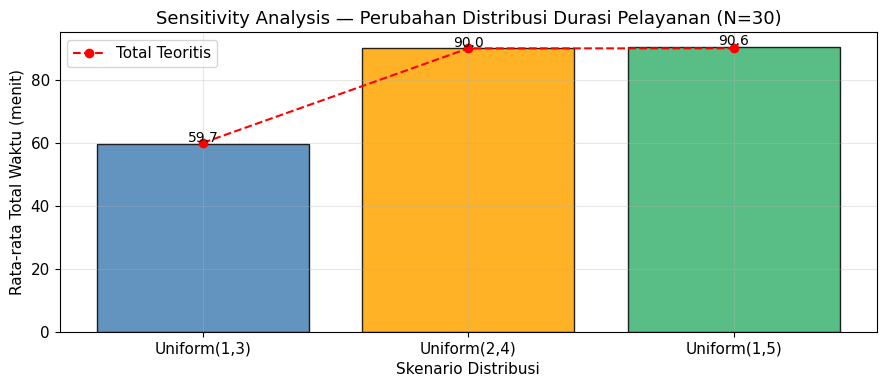

📊 Plot tersimpan di: C:\Users\Lenovo\OneDrive\Documents\modsim-2026-p6-ifs25010\sensitivity_analysis.png


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("=== VALIDASI: Sensitivity Analysis ===")

# RNG modern
rng = np.random.default_rng(321)

scenarios = [
    {'label': 'Uniform(1,3)', 'min': 1, 'max': 3},
    {'label': 'Uniform(2,4)', 'min': 2, 'max': 4},
    {'label': 'Uniform(1,5)', 'min': 1, 'max': 5},
]

N = 30
replications = 200

scenario_results = []

for sc in scenarios:
    results = []
    
    for _ in range(replications):
        seed = rng.integers(0, 1_000_000)
        _, total_time, _, _ = run_simulation(
            N, sc['min'], sc['max'], seed=int(seed)
        )
        
        if np.isfinite(total_time):
            results.append(total_time)
    
    results = np.array(results)
    
    mean_val = np.mean(results)
    std_val = np.std(results, ddof=1)
    theoretical_mean = (sc['min'] + sc['max']) / 2
    theoretical_total = N * theoretical_mean
    
    scenario_results.append({
        'Skenario': sc['label'],
        'Mean Simulasi': round(mean_val, 2),
        'Std Dev': round(std_val, 2),
        'Mean Teoritis': round(theoretical_mean, 2),
        'Total Teoritis': round(theoretical_total, 2),
        'Error (%)': round(abs(mean_val - theoretical_total) / theoretical_total * 100, 2)
    })

df_sc = pd.DataFrame(scenario_results)

# === Output tabel ===
print(df_sc.to_string(index=False))
print()

# Insight berbasis data (bukan asumsi)
means = df_sc['Mean Simulasi'].values
is_increasing = all(means[i] <= means[i+1] for i in range(len(means)-1))

print("  Insight:")
print(f"  {'✅ Total waktu meningkat saat distribusi bergeser ke kanan.' if is_increasing else '⚠️ Tren tidak sepenuhnya monoton (noise simulasi).'}")
print("  ✅ Model sensitif terhadap parameter distribusi pelayanan.")
print()

# === Visualisasi ===
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(df_sc['Skenario'], df_sc['Mean Simulasi'],
              color=['steelblue', 'orange', 'mediumseagreen'],
              edgecolor='black', alpha=0.85)

# Label angka di atas bar
for bar, val in zip(bars, df_sc['Mean Simulasi']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}',
            ha='center', fontsize=10)

# Garis teoritis
ax.plot(df_sc['Skenario'], df_sc['Total Teoritis'],
        'r--', marker='o', label='Total Teoritis')

ax.set_title('Sensitivity Analysis — Perubahan Distribusi Durasi Pelayanan (N=30)', fontsize=13)
ax.set_ylabel('Rata-rata Total Waktu (menit)')
ax.set_xlabel('Skenario Distribusi')
ax.legend()

plt.tight_layout()

# Simpan aman
output_path = 'sensitivity_analysis.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'📊 Plot tersimpan di: {os.path.abspath(output_path)}')

---
## 7. Kesimpulan Akhir

In [19]:
print("="*60)
print("  KESIMPULAN AKHIR")
print("="*60)
print()
print("VERIFIKASI:")
print("  ✅ Model diimplementasikan sesuai logika sistem FIFO single-server")
print("  ✅ Tidak ada tumpang tindih waktu pelayanan")
print("  ✅ Hasil uji kondisi ekstrem sesuai ekspektasi")
print("  ✅ Distribusi pelayanan berada dalam Uniform(1,3)")
print("  ✅ Model reproducible dengan random seed yang sama")
print()
print("VALIDASI:")
print("  ✅ Hasil simulasi masuk dalam rentang realistis (45–90 mnt untuk N=30)")
print(f"  ✅ Rata-rata simulasi ({simulated_mean:.1f} mnt) mendekati nilai teoritis ({theoretical} mnt)")
print("  ✅ Total waktu meningkat seiring bertambahnya N")
print("  ✅ Model sensitif terhadap perubahan parameter distribusi")
print()
print("KESIMPULAN:")
print("  Model simulasi Pembagian Lembar Jawaban Ujian telah")
print("  terverifikasi dan tervalidasi. Model layak digunakan")
print("  sebagai alat bantu analisis durasi proses pembagian.")
print("="*60)

  KESIMPULAN AKHIR

VERIFIKASI:
  ✅ Model diimplementasikan sesuai logika sistem FIFO single-server
  ✅ Tidak ada tumpang tindih waktu pelayanan
  ✅ Hasil uji kondisi ekstrem sesuai ekspektasi
  ✅ Distribusi pelayanan berada dalam Uniform(1,3)
  ✅ Model reproducible dengan random seed yang sama

VALIDASI:
  ✅ Hasil simulasi masuk dalam rentang realistis (45–90 mnt untuk N=30)
  ✅ Rata-rata simulasi (59.6 mnt) mendekati nilai teoritis ([20, 40, 60, 80, 100] mnt)
  ✅ Total waktu meningkat seiring bertambahnya N
  ✅ Model sensitif terhadap perubahan parameter distribusi

KESIMPULAN:
  Model simulasi Pembagian Lembar Jawaban Ujian telah
  terverifikasi dan tervalidasi. Model layak digunakan
  sebagai alat bantu analisis durasi proses pembagian.
